## ANOVA Test on Real Dataset — Student Performance (Kaggle)

**Dataset:** StudentsPerformance.csv
**Download from:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

**Question:**
Does parental level of education affect students' math scores?

**H0:** Mean math score is EQUAL across all parental education levels
**H1:** At least one group has a significantly different mean math score

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

In [4]:
df = pd.read_csv("/content/StudentsPerformance[1].csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print(df['parental level of education'].value_counts())

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64


In [9]:
summary = df.groupby('parental level of education')['math score'].agg(
    mean = 'mean',
    std = 'std',
    n = 'count'
)

print(summary)

                                  mean        std    n
parental level of education                           
associate's degree           67.882883  15.112093  222
bachelor's degree            69.389831  14.943789  118
high school                  62.137755  14.539651  196
master's degree              69.745763  15.153915   59
some college                 67.128319  14.312897  226
some high school             63.497207  15.927989  179


In [18]:
groups = [df[df["parental level of education"] == level]["math score"]
               for level in df["parental level of education"].unique()]

f_stat, p_val = f_oneway(*groups)

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value : {p_val:.6f}")

print(f"\nResult")
if p_val < 0.05:
    print("Reject H0 → Parental Education DOES significantly affect Math Scores")
else:
    print("Accept H0 → Parental Education does NOT significantly affect Math Scores")

F-Statistic : 6.5216
P-Value : 0.000006

Result
Reject H0 → Parental Education DOES significantly affect Math Scores


/tmp/ipykernel_13617/760143841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="parental level of education", y="math score", palette="Set2")


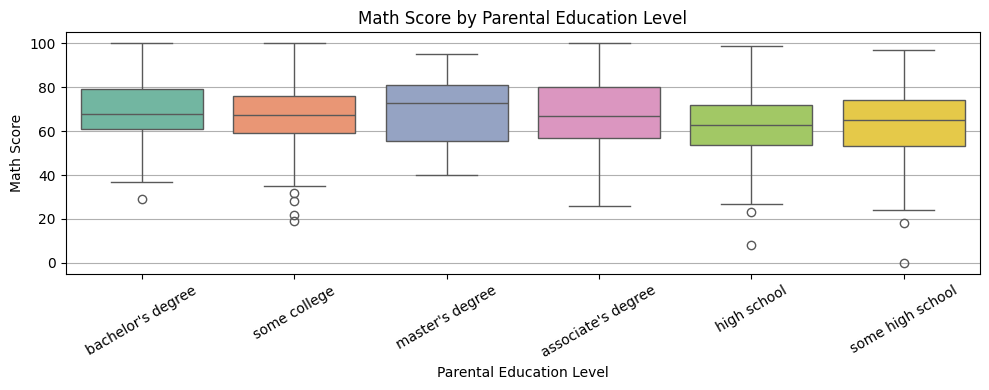

In [20]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x="parental level of education", y="math score", palette="Set2")
plt.title("Math Score by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Math Score")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.tight_layout()
plt.show()